# <b> Hospital Emergency Department Operations Analysis

## <b>Business Understanding

### <b>Vấn đề hiện tại (Business Problem)<b>

<b>Bệnh viện đang đối mặt với các vấn đề:<b>
    
- Thời gian chờ khám cấp cứu kéo dài  
- Mức độ hài lòng của bệnh nhân thấp  
- Phân bổ nguồn lực chưa hiệu quả  

### <b>Mục tiêu hướng đến (Business Goal)<b>

<b>Sử dụng dữ liệu để cải thiện:<b>
- Rút ngắn thời gian chờ tại khoa cấp cứu (ED waiting time)
- Nâng cao mức độ hài lòng của bệnh nhân
- Tối ưu hiệu quả vận hành bệnh viện

## <b>Import thư viện</b>

In [1]:
!pip install ydata-profiling -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
%matplotlib inline

### <b>1. Đọc và tìm hiểu dữ liệu

In [3]:
data = pd.read_csv('hospital_operation_clean.csv')

In [4]:
data.head()

,patient_admission_date,patient_admission_time,patient_id,merged,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime
0,2024-09-09,20:33:00,404-43-9499,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
1,2024-09-09,19:25:00,552-51-5855,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36
2,2024-09-09,13:14:00,536-68-0475,T. Shillaker,Female,25,African American,General Practice,Admission,6.0,14
3,2023-09-09,13:19:00,215-29-2936,B. Emberson,Female,44,African American,NaN,Admission,NaN,53
4,2023-09-09,23:21:00,824-34-1887,A. Coushe,Male,42,African American,NaN,Admission,NaN,54


In [5]:
data.tail()

,patient_admission_date,patient_admission_time,patient_id,merged,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime
9211,2023-10-01,04:06:00,636-65-9131,C. Melladew,Female,74,White,NaN,Not Admission,NaN,40
9212,2023-10-01,08:27:00,802-43-8558,O. Pusey,Female,57,White,NaN,Not Admission,NaN,11
9213,2024-01-01,12:55:00,533-87-1299,E. Brownlee,Female,28,White,NaN,Not Admission,NaN,57
9214,2024-01-01,23:01:00,353-25-3957,S. Levermore,Male,19,White,Cardiology,Not Admission,NaN,34
9215,2024-01-01,04:59:00,641-52-3173,L. Harford,Female,37,White,NaN,Not Admission,5.0,10


In [6]:
data.shape

(9216, 11)

#### <b> Nhận xét sơ lược   
- Dataset có **9216 dòng** và **11 cột**
- Duplicate values: **Không có**

Qua bộ dữ liệu có thể biết được:
- Thời gian chờ tại phòng cấp cứu của mỗi bệnh nhân
- Số ca mỗi khoa phụ trách
- Quyết định nhập viện của bệnh nhân

### <b>2. Làm sạch dữ liệu

<b>Loại bỏ dữ liệu không có giá trị phân tích

In [7]:
drop_cols = ['patient_id', 'merged']
data.drop(drop_cols, axis = 1, inplace = True)

data.head()

,patient_admission_date,patient_admission_time,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime
0,2024-09-09,20:33:00,Male,79,African American,General Practice,Admission,NaN,38
1,2024-09-09,19:25:00,Female,24,African American,NaN,Admission,NaN,36
2,2024-09-09,13:14:00,Female,25,African American,General Practice,Admission,6.0,14
3,2023-09-09,13:19:00,Female,44,African American,NaN,Admission,NaN,53
4,2023-09-09,23:21:00,Male,42,African American,NaN,Admission,NaN,54


<b> Kiểm tra dữ liệu thiếu

In [8]:
missing = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(data)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

,Missing Count,Missing %
patient_satisfaction_score,6699,72.688802
department_referral,5400,58.593750
patient_admission_date,0,0.000000
patient_admission_time,0,0.000000
patient_gender,0,0.000000
patient_race,0,0.000000
patient_age,0,0.000000
patient_admission_flag,0,0.000000
patient_waittime,0,0.000000


In [9]:
# Nhận xét 
# department_referral (58.6%) 
#     → Chuyển thành giá trị 'None', vì có những bệnh nhân không cần điều trị chuyên khoa.  
# patient_satisfaction_score (72.7%) 
#     → Giữ NaN (không fill), chỉ phân tích trên dữ liệu có giá trị  
#     → Tạo thêm cờ missing để kiểm tra bias do thiếu dữ liệu đánh giá.  

In [10]:
# Xử lí cột 'department_referral' 

data['department_referral'] = data['department_referral'].fillna('None')

In [11]:
# Xử lí cột 'patient_satisfaction_score'

# Tạo missing flag cho patient_satisfaction_score
data['satisfaction_missing_flag'] = data['patient_satisfaction_score'].isna().astype(int)

# Kiểm tra số lượng và tỷ lệ missing
data['satisfaction_missing_flag'].value_counts()

satisfaction_missing_flag
1    6699
0    2517
Name: count, dtype: int64

<b> Kiểm tra missing bias cột 'patient_satisfaction_score'

In [12]:
data['satisfaction_missing_flag'].value_counts(normalize=True) * 100

satisfaction_missing_flag
1    72.688802
0    27.311198
Name: proportion, dtype: float64

In [13]:
# So sánh wait time giữa nhóm missing và non-missing
data.groupby('satisfaction_missing_flag')['patient_waittime'].describe()

,count,mean,std,min,25%,50%,75%,max
satisfaction_missing_flag,,,,,,,,
0,2517.0,35.351212,14.852207,10.0,23.0,36.0,48.0,60.0
1,6699.0,35.225556,14.692134,10.0,23.0,35.0,48.0,60.0


In [14]:
# So sánh department giữa nhóm missing và non-missing
pd.crosstab(
    data['department_referral'],
    data['satisfaction_missing_flag'],
    normalize='columns'
) * 100

satisfaction_missing_flag,0,1
department_referral,,
Cardiology,2.820818,2.642185
Gastroenterology,2.145411,1.851023
General Practice,19.984108,19.958203
Neurology,2.105681,2.089864
None,57.210965,59.113300
Orthopedics,11.521653,10.523959
Physiotherapy,3.297576,2.881027
Renal,0.913786,0.940439


In [15]:
# So sánh theo giờ

# Tạo cột hour từ patient_admission_time
data['patient_hour'] = pd.to_datetime(
    data['patient_admission_time'],
    format='%H:%M:%S'
).dt.hour

data[['patient_admission_time', 'patient_hour']].head()

,patient_admission_time,patient_hour
0,20:33:00,20
1,19:25:00,19
2,13:14:00,13
3,13:19:00,13
4,23:21:00,23


In [16]:
pd.crosstab(
    data['patient_hour'],
    data['satisfaction_missing_flag'],
    normalize='columns'
) * 100

satisfaction_missing_flag,0,1
patient_hour,,
0,4.092173,4.523063
1,3.734605,4.149873
2,4.330552,3.985670
3,4.449742,4.075235
4,4.251093,4.134946
5,3.814064,4.433498
6,3.814064,4.164801
7,3.933254,4.717122
8,4.131903,4.209584


In [17]:
# Nhận xét
# Missing satisfaction score chưa cho thấy bias rõ rệt → giữ nguyên NaN

<b> Kiểm tra giá trị các biến

In [18]:
cols = ['patient_gender', 'patient_race', 'department_referral', 'patient_admission_flag']

for col in cols:
    print(f"\nColumn: {col}")
    print(data[col].unique())


Column: patient_gender
['Male' 'Female' 'Femaleemale']

Column: patient_race
['African American' 'Asian' 'Declined to Identify'
 'Native American/Alaska Native' 'Pacific Islander' 'Two or More Races'
 'White']

Column: department_referral
['General Practice' 'None' 'Orthopedics' 'Cardiology' 'Gastroenterology'
 'Physiotherapy' 'Neurology' 'Renal']

Column: patient_admission_flag
['Admission' 'Not Admission']


In [19]:
# Nhận xét
# Sửa typo trong patient_gender: 'Femaleemale' -> 'Female'

In [20]:
data['patient_gender'].value_counts()

patient_gender
Male           4729
Female         4470
Femaleemale      17
Name: count, dtype: int64

In [21]:
data['patient_gender'] = data['patient_gender'].replace('Femaleemale','Female')
data['patient_gender'].value_counts()

patient_gender
Male      4729
Female    4487
Name: count, dtype: int64

<b> Kiểm tra kiểu dữ liệu

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_admission_date      9216 non-null   object 
 1   patient_admission_time      9216 non-null   object 
 2   patient_gender              9216 non-null   object 
 3   patient_age                 9216 non-null   int64  
 4   patient_race                9216 non-null   object 
 5   department_referral         9216 non-null   object 
 6   patient_admission_flag      9216 non-null   object 
 7   patient_satisfaction_score  2517 non-null   float64
 8   patient_waittime            9216 non-null   int64  
 9   satisfaction_missing_flag   9216 non-null   int64  
 10  patient_hour                9216 non-null   int32  
dtypes: float64(1), int32(1), int64(3), object(6)
memory usage: 756.1+ KB


In [23]:
# Nhận xét
# Kiểu dữ liệu chưa phù hợp. Chuyển datatype datetime & category.

In [24]:
# Datetime

# Admission date
data['patient_admission_date'] = pd.to_datetime(data['patient_admission_date'], format='%Y-%m-%d')

# Admission time
data['patient_admission_time'] = pd.to_datetime(data['patient_admission_time'], format='%H:%M:%S')

In [25]:
# Category

for col in cols:
    data[col] = data[col].astype('category')

In [26]:
# Kiểm tra lại kiểu dữ liệu
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   patient_admission_date      9216 non-null   datetime64[ns]
 1   patient_admission_time      9216 non-null   datetime64[ns]
 2   patient_gender              9216 non-null   category      
 3   patient_age                 9216 non-null   int64         
 4   patient_race                9216 non-null   category      
 5   department_referral         9216 non-null   category      
 6   patient_admission_flag      9216 non-null   category      
 7   patient_satisfaction_score  2517 non-null   float64       
 8   patient_waittime            9216 non-null   int64         
 9   satisfaction_missing_flag   9216 non-null   int64         
 10  patient_hour                9216 non-null   int32         
dtypes: category(4), datetime64[ns](2), float64(1), int32(1),

### <b>3. Phân tích tổng quan thống kê dữ liệu

In [27]:
data.describe(include = 'number')

,patient_age,patient_satisfaction_score,patient_waittime,satisfaction_missing_flag,patient_hour
count,9216.000000,2517.000000,9216.000000,9216.000000,9216.000000
mean,39.855143,4.992054,35.259874,0.726888,11.486328
std,22.755125,3.138043,14.735323,0.445582,6.955110
min,1.000000,0.000000,10.000000,0.000000,0.000000
25%,20.000000,2.000000,23.000000,0.000000,5.000000
50%,39.000000,5.000000,35.000000,1.000000,11.000000
75%,60.000000,8.000000,48.000000,1.000000,18.000000
max,79.000000,10.000000,60.000000,1.000000,23.000000


##### Nhận xét  
- Thời gian chờ trung bình khoảng 35 phút → vận hành ổn định ở cấp độ tổng quan.  
- Mức độ hài lòng trung bình khoảng 5/10 → trải nghiệm bệnh nhân còn nhiều dư địa cải thiện.  
- Dữ liệu bao phủ nhiều nhóm tuổi khác nhau → khoa cấp cứu phục vụ đa dạng đối tượng bệnh nhân.  

In [28]:
data.describe(include='category')

,patient_gender,patient_race,department_referral,patient_admission_flag
count,9216,9216,9216,9216
unique,2,7,8,2
top,Male,White,None,Admission
freq,4729,2571,5400,4612


##### Nhận xét  
- Phân bố giới tính tương đối cân bằng.  
- Phần lớn bệnh nhân không cần chuyển chuyên khoa.   
- Tỷ lệ nhập viện và không nhập viện tương đối cân bằng → cần phân tích sâu hơn theo thời gian chờ và khoa điều trị.  

### <b> 4. Phân tích phân phối dữ liệu và kiểm tra giá trị ngoại lai

<B> Cột patient_waittime

In [29]:
# IQR method
Q1 = data['patient_waittime'].quantile(0.25)
Q3 = data['patient_waittime'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['patient_waittime'] < lower_bound) |
    (data['patient_waittime'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Outlier percentage:", round(len(outliers) / len(data) * 100, 2), "%")

Number of outliers: 0
Outlier percentage: 0.0 %


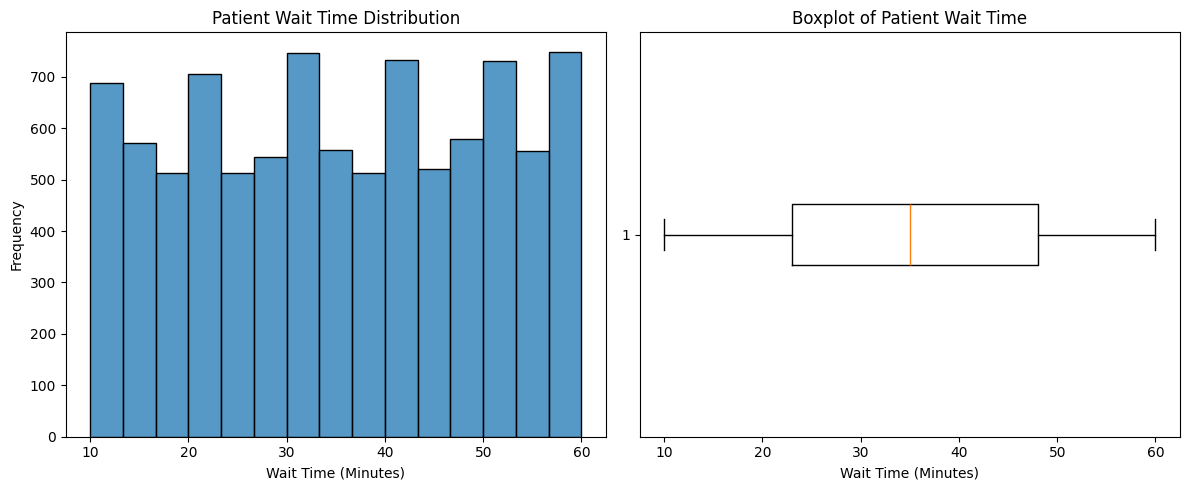

In [30]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)

sns.histplot( data=data, x='patient_waittime', bins=15)
plt.title('Patient Wait Time Distribution')
plt.xlabel('Wait Time (Minutes)')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)

plt.boxplot(data['patient_waittime'], vert=False)
plt.title('Boxplot of Patient Wait Time')
plt.xlabel('Wait Time (Minutes)')

plt.tight_layout()
plt.show()

##### Kết luận: 
Phân bố dữ liệu trải đều, không xuất hiện lệch phân phối quá mạnh.  
Không xuất hiện giá trị ngoại lai (outlier).

<b> Cột patient_satisfaction_score

In [31]:
# IQR method
Q1 = data['patient_satisfaction_score'].quantile(0.25)
Q3 = data['patient_satisfaction_score'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['patient_satisfaction_score'] < lower_bound) |
    (data['patient_satisfaction_score'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Outlier percentage:", round(len(outliers) / len(data) * 100, 2), "%")

Number of outliers: 0
Outlier percentage: 0.0 %


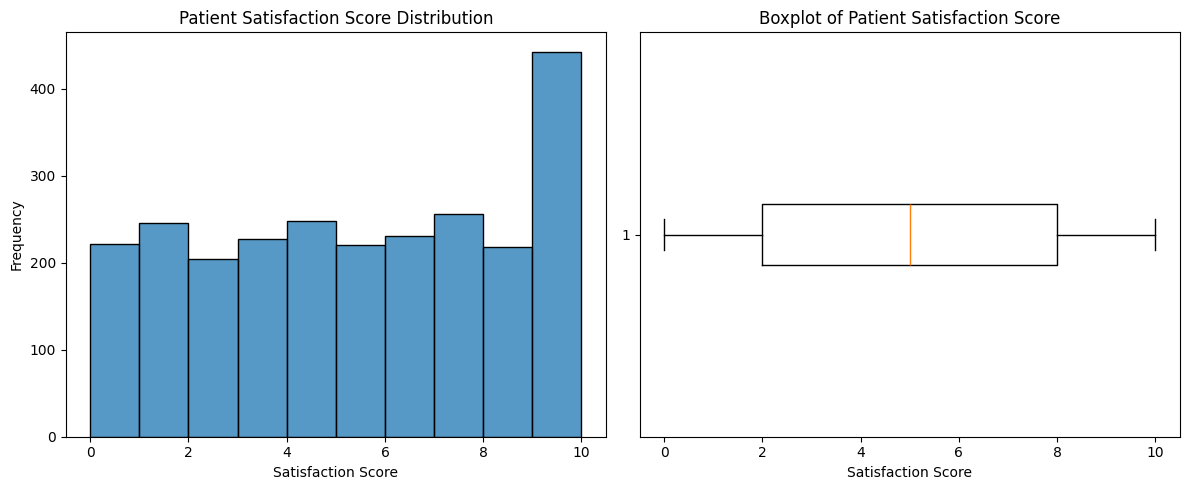

In [32]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)

sns.histplot( data=data, x='patient_satisfaction_score', bins=10)
plt.title('Patient Satisfaction Score Distribution')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)

plt.boxplot(data['patient_satisfaction_score'].dropna(), vert=False)
plt.title('Boxplot of Patient Satisfaction Score')
plt.xlabel('Satisfaction Score')

plt.tight_layout()
plt.show()

##### Kết luận: 
Nhóm bệnh nhân có mức hài lòng rất cao (score = 10) chiếm tỷ trọng đáng kể.  
Không xuất hiện giá trị ngoại lai (outlier).  
Tuy nhiên vẫn tồn tại nhóm bệnh nhân có độ hài lòng thấp → cần phân tích thêm  

### <b> 5. Tổng quan vận hành khoa cấp cứu

<b>Phân tích số lượng bệnh nhân theo thời gian</b>

In [33]:
# 1. Số lượng bệnh nhân theo giờ
volume_by_hour = data.groupby('patient_hour').size().reset_index(name='patient_count')

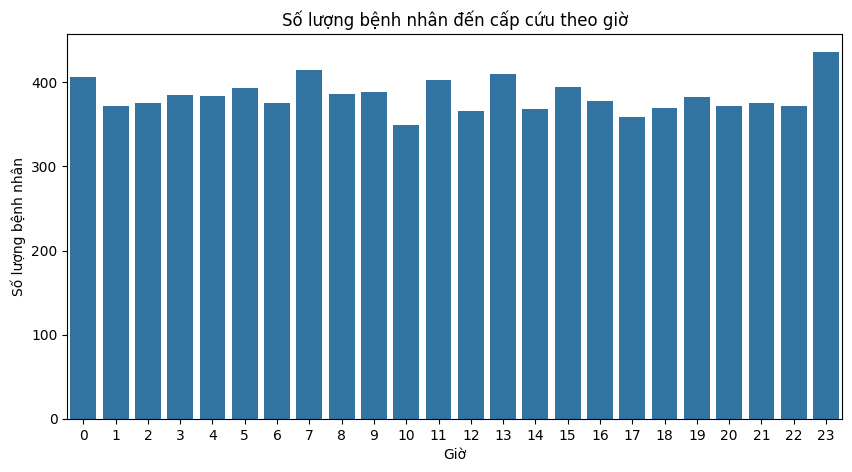

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=volume_by_hour, 
    x='patient_hour', 
    y='patient_count'
)

plt.title('Số lượng bệnh nhân đến cấp cứu theo giờ')
plt.xlabel('Giờ')
plt.ylabel('Số lượng bệnh nhân')

plt.show()

In [35]:
# Nhận xét:
# Khoa cấp cứu hoạt động gần như liên tục 24/7 với lượng bệnh nhân phân bổ khá đều theo giờ.
# Chưa xuất hiện dấu hiệu quá tải rõ rệt chỉ dựa trên số lượng bệnh nhân theo thời gian.

In [36]:
# 2. Số lượng bệnh nhân theo tháng
volume_by_month = (data.groupby(data['patient_admission_date'].dt.month).size().reset_index(name='patient_count'))
volume_by_month.columns = ['month', 'patient_count']

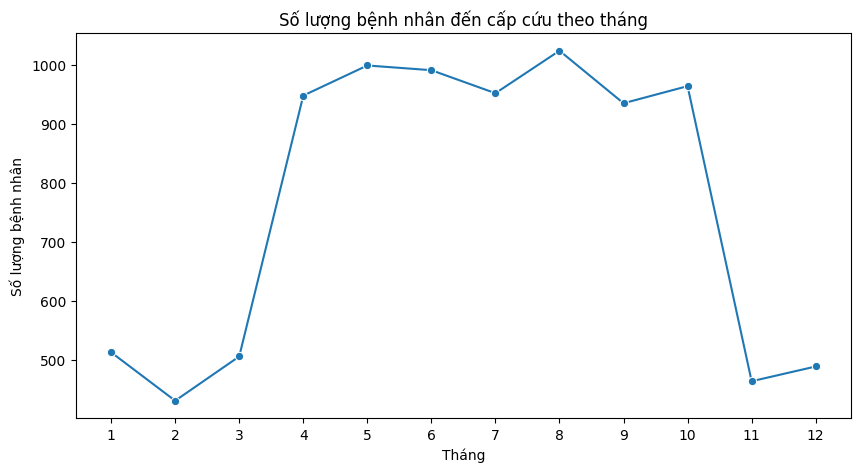

In [37]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=volume_by_month,
    x='month',
    y='patient_count',
    marker='o'
)

plt.title('Số lượng bệnh nhân đến cấp cứu theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số lượng bệnh nhân')

plt.xticks(volume_by_month['month'])

plt.show()

In [38]:
# Nhận xét:
# Lượng bệnh tại khoa cấp cứu tăng mạnh trong giai đoạn tháng 4–10, gần gấp đôi so với đầu và cuối năm.
# Tháng 8 ghi nhận số lượng bệnh nhân cao nhất, vượt 1000 ca.
# Cho thấy khối lượng công việc có tính mùa vụ khá rõ.

<b>Phân tích tình hình nhập viện</b>

In [39]:
# 1. Số lượng bệnh nhân nhập viện theo giờ
admission_by_hour = (
    data.groupby(['patient_hour', 'patient_admission_flag'])
    .size()
    .reset_index(name='patient_count')
)

C:\Users\VINH PHU\AppData\Local\Temp\ipykernel_3164\3963205281.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['patient_hour', 'patient_admission_flag'])


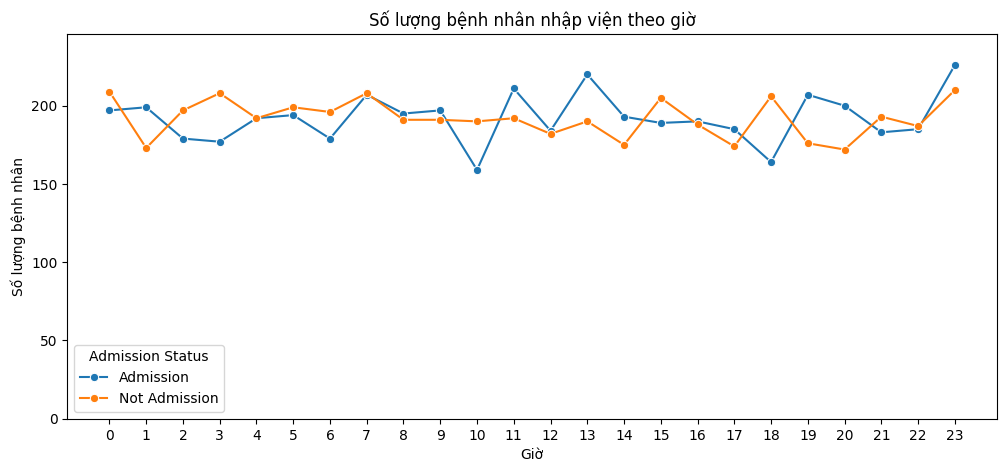

In [40]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=admission_by_hour,
    x='patient_hour',
    y='patient_count',
    hue='patient_admission_flag',
    marker='o'
)

plt.title('Số lượng bệnh nhân nhập viện theo giờ')
plt.xlabel('Giờ')
plt.ylabel('Số lượng bệnh nhân')

plt.xticks(range(24))
plt.legend(title='Admission Status')
plt.ylim(0, admission_by_hour['patient_count'].max() + 20)

plt.show()

In [41]:
# Nhận xét:
# Số lượng bệnh nhân nhập viện và không nhập viện phân bố khá ổn định theo giờ.
# Chưa xuất hiện thời gian cao điểm rõ rệt về số lượng bệnh nhân nhập viện.
# Một vài khung giờ có số lượng bệnh nhân nhập viện tăng nhẹ nhưng không chênh lệch lớn.

In [42]:
# 2. Số lượng bệnh nhân nhập viện theo khoa
admission_by_department = (
    data.groupby(['department_referral', 'patient_admission_flag'])
    .size()
    .reset_index(name='patient_count')
)

admission_by_department = admission_by_department[
    admission_by_department['department_referral'] != 'None'
].copy()

admission_by_department['department_referral'] = (
    admission_by_department['department_referral']
    .cat.remove_unused_categories()
)

C:\Users\VINH PHU\AppData\Local\Temp\ipykernel_3164\3921337210.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['department_referral', 'patient_admission_flag'])


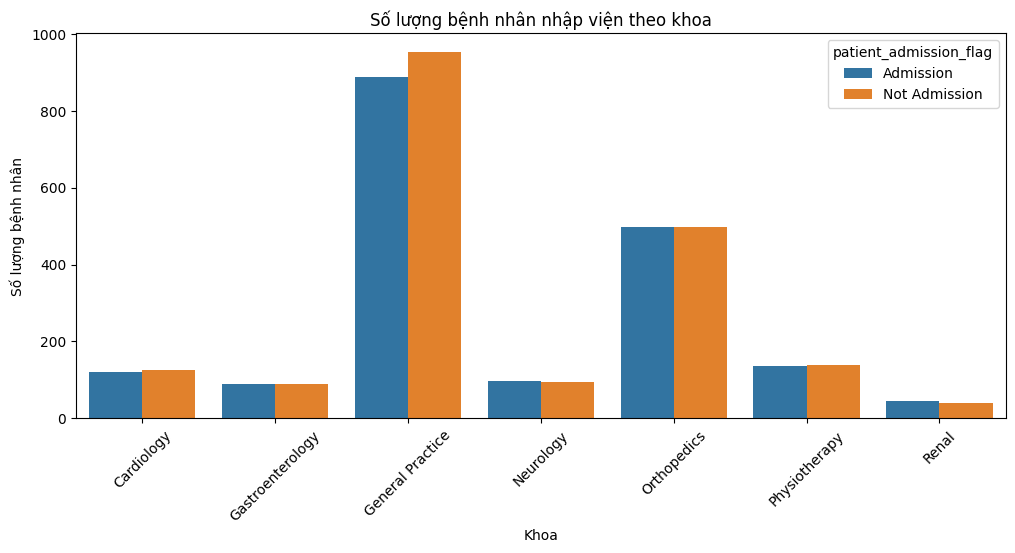

In [62]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=admission_by_department,
    x='department_referral',
    y='patient_count',
    hue='patient_admission_flag'
)

plt.title('Số lượng bệnh nhân nhập viện theo khoa')
plt.xlabel('Khoa')
plt.ylabel('Số lượng bệnh nhân')

plt.xticks(rotation=45)

plt.show()

In [44]:
# Nhận xét:
# General Practice và Orthopedics là hai khoa tiếp nhận nhiều bệnh nhân nhất.
# Tỷ lệ nhập viện và không nhập viện tại các khoa có phân bố khá cân bằng.
# Chưa thấy khoa nào có tỷ lệ nhập viện vượt trội rõ rệt.

<h4><b>Kết luận</b></h4>

<ul>
<li>Khoa cấp cứu vận hành với khối lượng công việc khá liên tục trong suốt 24 giờ, cho thấy nhu cầu cấp cứu ổn định thay vì chỉ tập trung vào một vài khung giờ cao điểm.</li>

<li>Mặc dù tồn tại một số khung giờ có số lượng bệnh nhân cao hơn trung bình, nhưng mức chênh lệch chưa đủ lớn để xem là cao điểm rõ rệt.</li>

<li>Số lượng bệnh nhân tăng mạnh trong giai đoạn tháng 4–10. Bệnh viện cần điều chỉnh phân bổ nhân sự theo mùa để tránh quá tải vận hành.</li>

<li>Tỷ lệ nhập viện phân bổ tương đối đồng đều theo giờ, cho thấy áp lực nhập viện không tập trung vào một thời điểm cụ thể trong ngày.</li>

<li>Ở cấp độ tổng quan vận hành, chưa xuất hiện dấu hiệu quá tải mạnh trên toàn hệ thống chỉ dựa trên số lượng bệnh nhân.</li>

### <b> 6. Phân tích điểm nghẽn vận hành theo khoa

In [45]:
# Loại bỏ giá trị 'None'
department_data = data[
    data['department_referral'] != 'None'
].copy()

department_data['department_referral'] = (
    department_data['department_referral']
    .cat.remove_unused_categories()
)

<b>Phân phối thời gian chờ theo khoa</b>

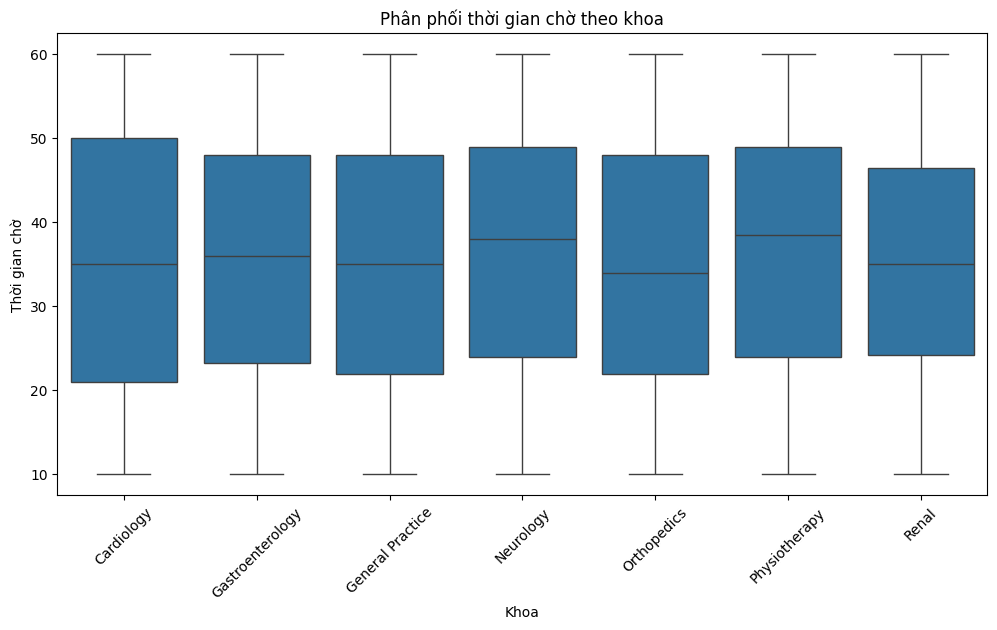

In [46]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=department_data,
    x='department_referral',
    y='patient_waittime'
)

plt.title('Phân phối thời gian chờ theo khoa')
plt.xlabel('Khoa')
plt.ylabel('Thời gian chờ')

plt.xticks(rotation=45)

plt.show()

In [47]:
# Nhận xét:
# Độ biến động thời gian chờ không khác biệt quá lớn giữa các khoa, median khá tương đồng.
# Chưa xuất hiện khoa nào có dấu hiệu quá tải rõ rệt.

<b>Khối lượng bệnh nhân vs thời gian chờ theo khoa</b>

In [48]:
dept_analysis = (
    department_data
    .groupby('department_referral')
    .agg(
        patient_count=('department_referral', 'size'),
        avg_waiting_time=('patient_waittime', 'mean'),
        median_waiting_time=('patient_waittime', 'median'),
        min_waiting_time=('patient_waittime', 'min'),
        max_waiting_time=('patient_waittime', 'max')
    )
    .reset_index()
)

dept_analysis = dept_analysis.sort_values(
    by='patient_count',
    ascending=False
)

dept_analysis

C:\Users\VINH PHU\AppData\Local\Temp\ipykernel_3164\5757810.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('department_referral')


,department_referral,patient_count,avg_waiting_time,median_waiting_time,min_waiting_time,max_waiting_time
2,General Practice,1840,34.912500,35.0,10,60
4,Orthopedics,995,34.982915,34.0,10,60
5,Physiotherapy,276,36.565217,38.5,10,60
0,Cardiology,248,35.354839,35.0,10,60
3,Neurology,193,36.803109,38.0,10,60
1,Gastroenterology,178,35.831461,36.0,10,60
6,Renal,86,34.697674,35.0,10,60


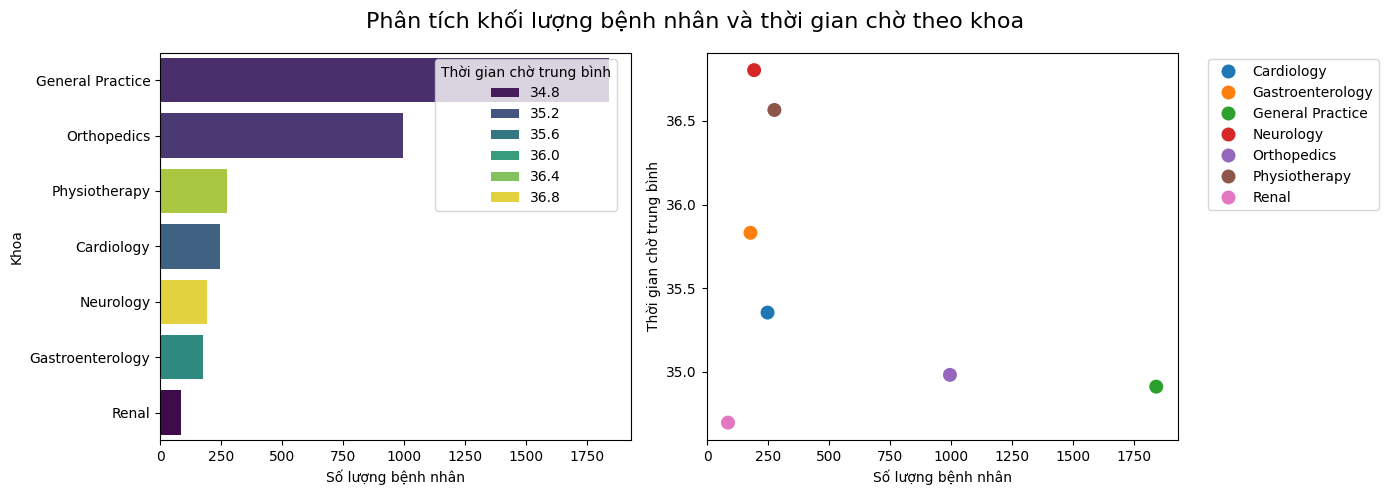

In [49]:
plt.figure(figsize=(14, 5))
plt.suptitle(
    'Phân tích khối lượng bệnh nhân và thời gian chờ theo khoa',
    fontsize=16
)

# Biểu đồ 1
plt.subplot(1, 2, 1)

sns.barplot(
    data=dept_analysis,
    x='patient_count',
    y='department_referral',
    hue='avg_waiting_time',
    palette='viridis',
    order=dept_analysis['department_referral']
)

plt.xlabel('Số lượng bệnh nhân')
plt.ylabel('Khoa')
plt.legend(
    title='Thời gian chờ trung bình',
    bbox_to_anchor=(0.57, 1),
    loc='upper left'
)

# Biểu đồ 2
plt.subplot(1, 2, 2)

sns.scatterplot(
    data=dept_analysis,
    x='patient_count',
    y='avg_waiting_time',
    hue='department_referral',
    s=120
)

plt.xlabel('Số lượng bệnh nhân')
plt.ylabel('Thời gian chờ trung bình')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()


In [50]:
# Nhận xét:
# General Practice và Orthopedics tiếp nhận nhiều bệnh nhân nhất.
# General Practice duy trì thời gian chờ ổn định dù khối lượng bệnh nhân lớn, trong khi Neurology có thời gian chờ cao hơn tương đối.
# Chưa xuất hiện mối quan hệ rõ ràng giữa khối lượng bệnh nhân và thời gian chờ theo khoa.

<h4><b>Kết luận</b></h4>

<ul>

<li>
General Practice và Orthopedics tiếp nhận lượng bệnh nhân cao nhất nhưng thời gian chờ vẫn tương đối ổn định, cho thấy chưa xuất hiện điểm nghẽn vận hành rõ rệt do khối lượng công việc.
</li>

<li>
Neurology có thời gian chờ thuộc nhóm cao nhất dù số lượng bệnh nhân thấp, cho thấy thời gian xử lý có thể chịu ảnh hưởng bởi tính chất chuyên môn hơn là áp lực bệnh nhân.
</li>

<li>
Phân phối thời gian chờ giữa các khoa nhìn chung khá tương đồng, chưa xuất hiện khoa nào có biến động bất thường hoặc dấu hiệu quá tải nghiêm trọng.
</li>

<li>
Kết quả cho thấy bottleneck vận hành hiện chưa đến từ áp lực số lượng bệnh nhân toàn hệ thống mà nhiều khả năng liên quan đến đặc thù xử lý của từng chuyên khoa.
</li>

</ul>

### <b> 7. Khối lượng công việc và thời gian chờ

In [51]:
# Tạo cột tháng từ datetime
data['patient_month'] = data['patient_admission_date'].dt.month

<b>Khối lượng công việc và thời gian chờ theo tháng</b>

In [52]:
waiting_by_month = (
    data
    .groupby('patient_month')
    .agg(
        patient_count=('patient_waittime', 'size'),
        avg_waiting_time=('patient_waittime', 'mean'),
        median_waiting_time=('patient_waittime', 'median')
    )
    .reset_index()
)

waiting_by_month

,patient_month,patient_count,avg_waiting_time,median_waiting_time
0,1,513,36.323587,37.0
1,2,431,36.670534,37.0
2,3,506,35.879447,36.0
3,4,948,34.972574,35.0
4,5,999,35.146146,35.0
5,6,991,35.544904,37.0
6,7,952,34.965336,35.0
7,8,1024,35.730469,36.0
8,9,935,34.663102,34.0
9,10,964,34.502075,34.0


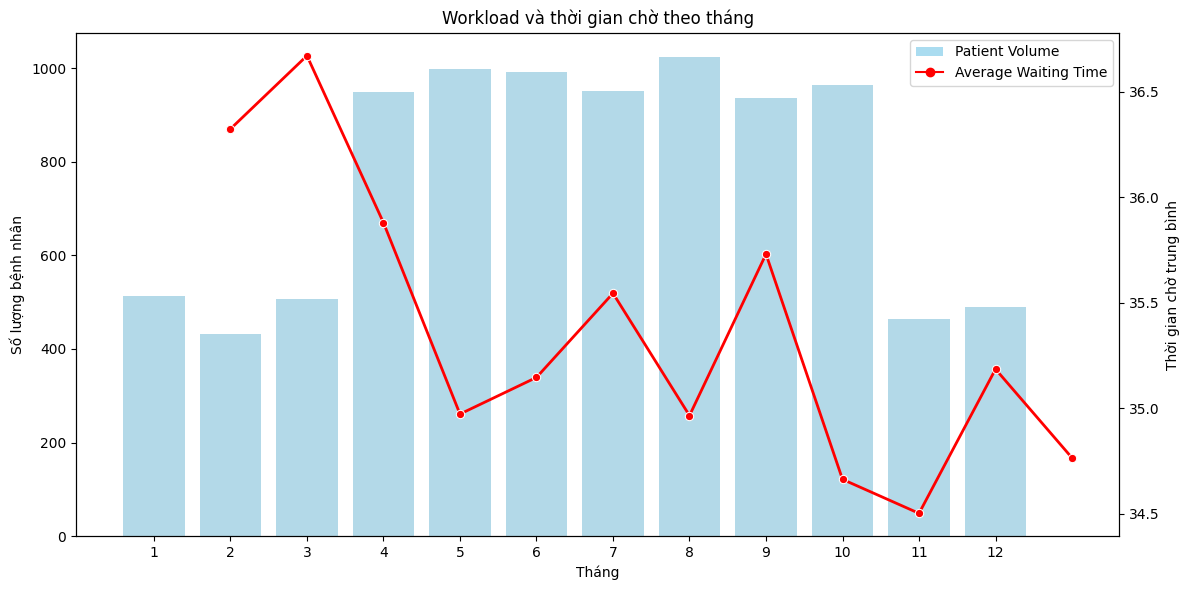

In [53]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barplot
sns.barplot(
    data=waiting_by_month,
    x='patient_month',
    y='patient_count',
    color='skyblue',
    alpha=0.7,
    ax=ax1
)

ax1.set_xlabel('Tháng')
ax1.set_ylabel('Số lượng bệnh nhân')

# Lineplot
ax2 = ax1.twinx()

sns.lineplot(
    data=waiting_by_month,
    x='patient_month',
    y='avg_waiting_time',
    marker='o',
    color='red',
    linewidth=2,
    ax=ax2
)

ax2.set_ylabel('Thời gian chờ trung bình')

# Custom legend
legend_elements = [
    Patch(facecolor='skyblue', alpha=0.7, label='Patient Volume'),
    Line2D([0], [0], color='red', marker='o', label='Average Waiting Time')
]

ax1.legend(handles=legend_elements, loc='upper right')

plt.title('Workload và thời gian chờ theo tháng')

plt.tight_layout()
plt.show()

In [54]:
# Nhận xét:
# Thời gian chờ trung bình không tăng tương ứng với seasonal workload
# Hệ thống vận hành ổn định trong giai đoạn cao điểm tháng 4 - 10
# Khối lượng công việc theo tháng không phải yếu tố chính gây tăng thời gian chờ.

<h4><b>Kết luận</b></h4>

<ul>

<li>
Khối lượng bệnh nhân tại khoa cấp cứu có xu hướng tăng theo mùa, đặc biệt trong giai đoạn tháng 4–10. Tuy nhiên, thời gian chờ trung bình vẫn duy trì tương đối ổn định và không tăng mạnh theo khối lượng bệnh nhân.

<li>
Kết quả cho thấy áp lực vận hành theo mùa hiện chưa phải nguyên nhân chính làm gia tăng thời gian chờ và chưa tạo ra tình trạng quá tải nghiêm trọng trên toàn hệ thống.

<li>
Tuy vậy, bộ dữ liệu vẫn còn thiếu nhiều yếu tố vận hành quan trọng như mức độ nghiêm trọng của bệnh nhân, số lượng nhân sự y tế, mức độ ưu tiên cấp cứu và số lượng bệnh nhân trong hàng đợi, nên chưa đủ cơ sở để xác định chính xác nguyên nhân cốt lõi ảnh hưởng đến thời gian chờ.</li>

</ul>

### <b> 8. Phân tích nhóm bệnh nhân chờ lâu // Phân tích các trường hợp có thời gian chờ lâu

<b>Xác định ngưỡng nhóm có thời gian chờ lâu

In [64]:
# Ngưỡng Top 10% các trương hợp có thời gian chờ lâu nhất

long_wait_threshold = data["patient_waittime"].quantile(0.90)

print(f"Ngưỡng nhóm chờ lâu: {long_wait_threshold:.2f} phút")

# Tạo cờ long wait

data["long_wait"] = data["patient_waittime"] >= long_wait_threshold

# Kiểm tra

data["long_wait"].value_counts(normalize=True) * 100

Top 10% threshold: 56.00 phút


long_wait
False    89.854601
True     10.145399
Name: proportion, dtype: float64

<b>Tỷ lệ và số lượng bệnh nhân chờ lâu theo khoa

In [87]:
# Loại bỏ giá trị 'None'
department_data = data[
    data["department_referral"] != "None"
].copy()

department_data["department_referral"] = (
    department_data["department_referral"]
    .cat.remove_unused_categories()
)

In [86]:
dept_long_wait_summary = (
    department_data
    .groupby("department_referral", observed=True)
    .agg(
        patient_count=("department_referral", "size"),
        long_wait_cases=("long_wait", "sum"),
        long_wait_rate=("long_wait", "mean")
    )
    .reset_index()
)

dept_long_wait_summary["long_wait_rate"] = (
    dept_long_wait_summary["long_wait_rate"] * 100
)

dept_long_wait_summary = (
    dept_long_wait_summary
    .sort_values("long_wait_cases", ascending=False)
)

dept_long_wait_summary

,department_referral,patient_count,long_wait_cases,long_wait_rate
2,General Practice,1840,186,10.108696
4,Orthopedics,995,104,10.452261
5,Physiotherapy,276,35,12.681159
0,Cardiology,248,28,11.290323
3,Neurology,193,24,12.435233
1,Gastroenterology,178,18,10.112360
6,Renal,86,6,6.976744


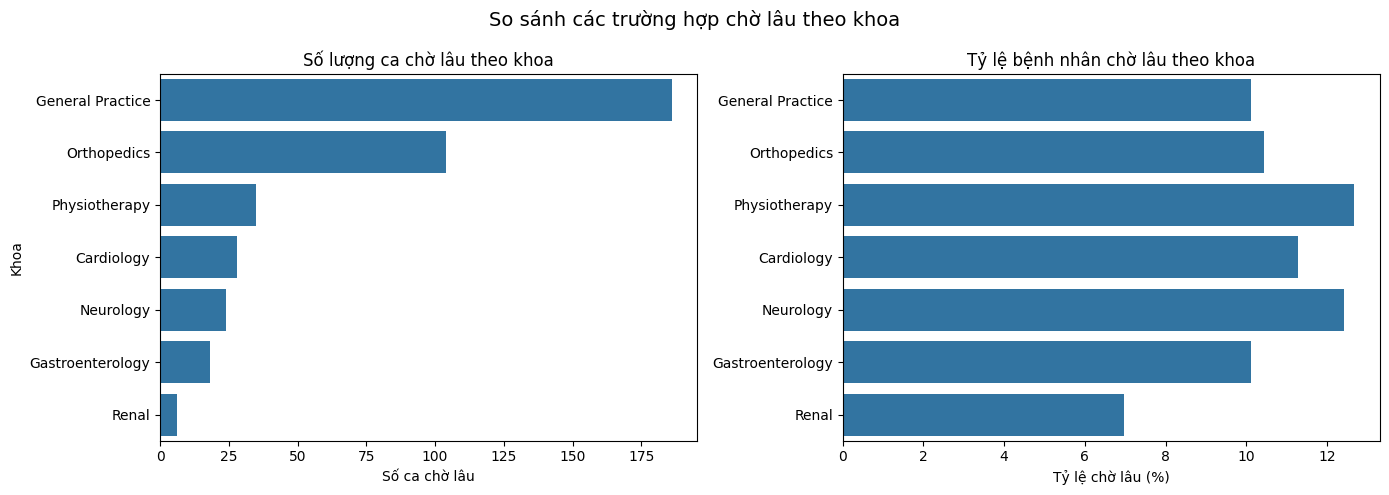

In [88]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14,5)
)

# Số lượng ca chờ lâu theo khoa
sns.barplot(
    data=dept_long_wait_summary,
    x="long_wait_cases",
    y="department_referral",
    order=dept_long_wait_summary["department_referral"],
    ax=axes[0]
)

axes[0].set_title("Số lượng ca chờ lâu theo khoa")
axes[0].set_xlabel("Số ca chờ lâu")
axes[0].set_ylabel("Khoa")

# Tỷ lệ bệnh nhân chờ lâu theo khoa
sns.barplot(
    data=dept_long_wait_summary,
    x="long_wait_rate",
    y="department_referral",
    order=dept_long_wait_summary["department_referral"],
    ax=axes[1]
)

axes[1].set_title("Tỷ lệ bệnh nhân chờ lâu theo khoa")
axes[1].set_xlabel("Tỷ lệ chờ lâu (%)")
axes[1].set_ylabel("")

plt.suptitle(
    "So sánh các trường hợp chờ lâu theo khoa",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
# Nhận xét
# Tỷ lệ bệnh nhân thuộc nhóm chờ lâu khá đồng đều giữa các khoa (khoảng 7%–13%), chưa cho thấy sự tập trung rõ rệt tại một khoa cụ thể.

<h4><b>Kết luận</b></h4>

<ul>

<li>
Các trường hợp chờ lâu phân bố tương đối đồng đều giữa các khoa và không tập trung rõ rệt tại một khoa cụ thể. </li>

<li>
Số lượng ca chờ lâu cao chủ yếu xuất hiện ở các khoa có khối lượng bệnh nhân lớn, thay vì do tỷ lệ chờ lâu bất thường.
</li>

</ul>

## <b> Khuyến nghị vận hành

### <b> Khuyến nghị 1: Điều chỉnh nguồn lực theo mùa</b>

#### Cơ sở dữ liệu

- Lượng bệnh nhân tăng mạnh từ tháng 4–10.
- Tháng 8 ghi nhận khối lượng bệnh nhân cao nhất.

#### Khuyến nghị

- Điều chỉnh kế hoạch nhân sự theo mùa thay vì duy trì cố định quanh năm.
- Tăng cường nguồn lực trong giai đoạn cao điểm để đảm bảo chất lượng dịch vụ.

---

### <b> Khuyến nghị 2: Theo dõi sát các khoa có khối lượng bệnh nhân lớn </b>

#### Cơ sở dữ liệu

- General Practice và Orthopedics tiếp nhận nhiều bệnh nhân nhất.

#### Khuyến nghị

- Theo dõi định kỳ khối lượng bệnh nhân và thời gian chờ tại các khoa này.
- Ưu tiên phân bổ nguồn lực cho các khoa có khối lượng bệnh nhân lớn.

---

### <b> Khuyến nghị 3: Giám sát các khoa có thời gian chờ cao hơn tương đối </b>

#### Cơ sở dữ liệu

- Neurology và Physiotherapy có thời gian chờ trung bình thuộc nhóm cao hơn các khoa còn lại.

#### Khuyến nghị

- Đánh giá quy trình tiếp nhận và xử lý bệnh nhân tại các khoa này.
- Xác định các bước chuyên môn có khả năng làm kéo dài thời gian chờ.

---

### <b> Khuyến nghị 4: Bổ sung dữ liệu vận hành </b>

#### Cơ sở dữ liệu

- Dữ liệu hiện tại chưa đủ để xác định nguyên nhân gốc rễ ảnh hưởng đến thời gian chờ.

#### Khuyến nghị

Thu thập thêm các thông tin:

- Mức độ ưu tiên cấp cứu (Acuity Level)
- Số lượng nhân sự theo ca trực
- Số lượng bệnh nhân trong hàng đợi
- Thời gian điều trị hoặc thăm khám

---

### <b> Kết luận </b>

Dữ liệu hiện tại chưa cho thấy dấu hiệu quá tải rõ rệt trên toàn hệ thống.   
Tuy nhiên, bệnh viện nên tập trung vào tối ưu nguồn lực theo mùa, giám sát các khoa có khối lượng bệnh nhân lớn và bổ sung dữ liệu vận hành để hiểu rõ hơn các yếu tố ảnh hưởng đến thời gian chờ.